# Notebook 2 — Axial Rig Design Analysis
## Reachability Envelope · Shaft Torque · Tip Mach · Flow Coefficients · Inlet Angle Sweep

**Design objectives (from project brief)**
| Parameter | Value / Range |
|-----------|---------------|
| Stage type | Single-stage axial (rotor + stator, IGV optional) |
| Tip diameter | 700 – 1000 mm |
| Pressure ratio | 1.1 – 1.2 |
| Blade height | ≥ 50 mm |
| Shaft speed | 3 000 – 4 000 RPM (direct motor drive) |
| Available motors | 250 · 300 · 400 · 500 kW |
| Test Reynolds range | 300 000 – 800 000 |
| Test Mach range | 0.30 – 0.45 |
| Isentropic efficiency | 70 % (conservative / reachability basis) |

**Motor selection rule (from Notebook 1):** Take the next higher standard induction motor rating above the swept power requirement.  
The meanline sweep in Notebook 1 shows peak power ≈ 329 kW → **selected motor: 400 kW**.

---

## 0. Imports & Constants

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore')

# ── Fluid properties (air, standard atmosphere) ──────────────────────────────
gamma   = 1.4          # ratio of specific heats
R_air   = 287.05       # J/(kg·K)
cp_air  = 1005.0       # J/(kg·K)  — used for power estimate

# ── Ambient / inlet conditions ────────────────────────────────────────────────
P0_in   = 101_325.0    # Pa  — inlet total pressure
T0_in   = 300.0        # K   — inlet total temperature

# ── Motor ─────────────────────────────────────────────────────────────────────
P_motor_kW  = 400.0        # kW — selected motor (next higher above 329 kW)
P_motor     = P_motor_kW * 1e3   # W

# ── Design constraints ────────────────────────────────────────────────────────
eta_is      = 0.70         # isentropic efficiency (reachability basis)
blade_h_min = 0.050        # m — minimum blade height
D_tip_range = np.array([0.700, 0.750, 0.800, 0.850, 0.900, 0.950, 1.000])  # m
RPM_range   = np.arange(3000, 4001, 200)                                    # rpm
PR_range    = np.array([1.10, 1.15, 1.20])                                  # —

# ── Test envelope targets ─────────────────────────────────────────────────────
Re_min, Re_max   = 3e5, 8e5
Ma_min, Ma_max   = 0.30, 0.45

# Blade height fixed at minimum (most conservative; can be varied)
blade_h = blade_h_min

print(f"Selected motor : {P_motor_kW:.0f} kW")
print(f"η_is (reachability) : {eta_is:.0%}")
print(f"Inlet conditions: P0={P0_in/1e3:.3f} kPa, T0={T0_in} K")

Selected motor : 400 kW
η_is (reachability) : 70%
Inlet conditions: P0=101.325 kPa, T0=300.0 K


---
## 1. Reachability Envelope

For each combination of tip diameter and shaft speed the deliverable shaft power is

$$\dot{W}_{\text{shaft}} = \dot{m}\,c_p\,T_{0,\text{in}}\,\left(PR^{\frac{\gamma-1}{\gamma}} - 1\right) / \eta_{is}$$

The annulus area and mass-flow are derived from the inlet axial velocity (set by the inlet Mach number) and density.  
A design point is **reachable** if:
1. Required shaft power ≤ 400 kW  
2. Inlet axial Mach number ∈ [0.30, 0.45]  
3. Inlet Reynolds number ∈ [300 000, 800 000]  
4. Blade height ≥ 50 mm

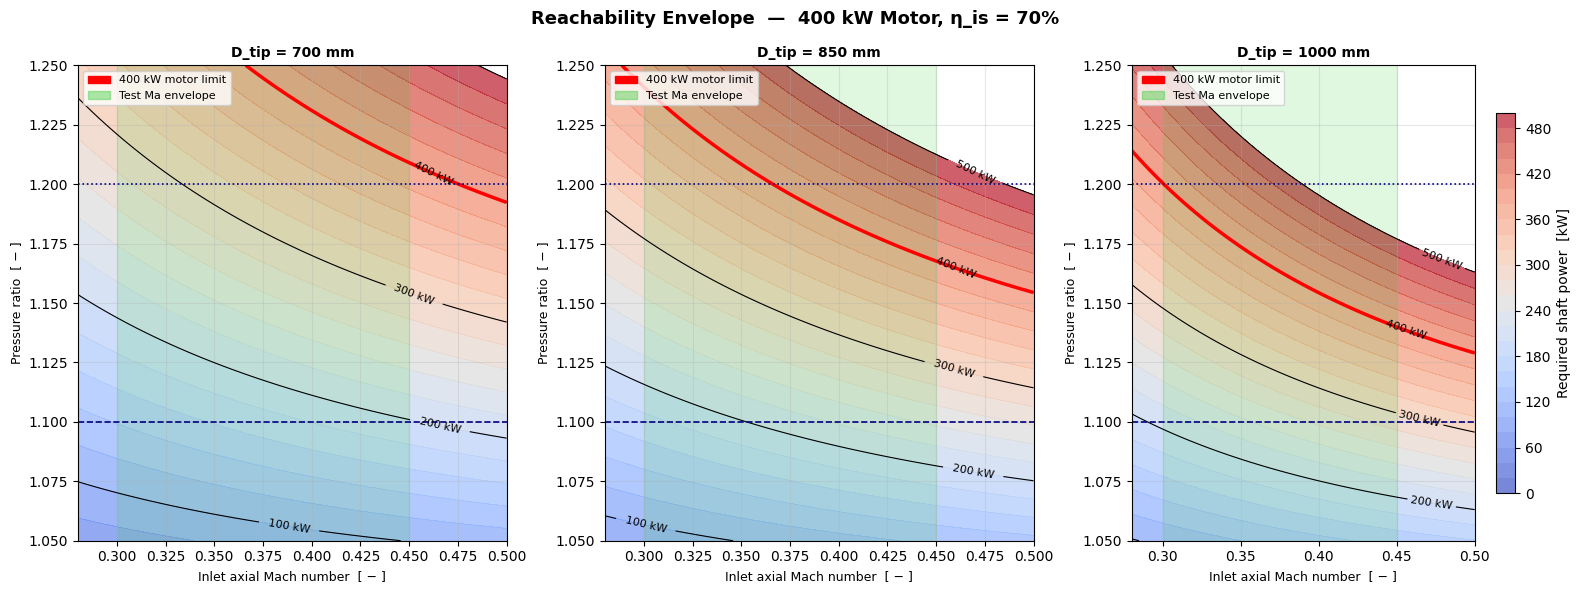

Figure saved: reachability_envelope.png


In [2]:
def speed_of_sound(T):
    return np.sqrt(gamma * R_air * T)

def isentropic_T_static(T0, Ma):
    return T0 / (1 + (gamma-1)/2 * Ma**2)

def isentropic_P_static(P0, Ma):
    return P0 / (1 + (gamma-1)/2 * Ma**2)**(gamma/(gamma-1))

def air_density(P, T):
    return P / (R_air * T)

def annulus_area(D_tip, blade_h):
    D_hub = D_tip - 2*blade_h
    return np.pi/4 * (D_tip**2 - D_hub**2)

def mass_flow(Ma_ax, D_tip, blade_h, P0, T0):
    Ts   = isentropic_T_static(T0, Ma_ax)
    Ps   = isentropic_P_static(P0, Ma_ax)
    rho  = air_density(Ps, Ts)
    a    = speed_of_sound(Ts)
    Vax  = Ma_ax * a
    A    = annulus_area(D_tip, blade_h)
    return rho * Vax * A

def required_power(mdot, PR, T0_in, eta_is):
    dh_is = cp_air * T0_in * (PR**((gamma-1)/gamma) - 1)
    return mdot * dh_is / eta_is

def chord_from_Re(Re, rho, Vax, mu=1.81e-5):
    """Back-calculate blade chord from a target Reynolds number."""
    return Re * mu / (rho * Vax)

def inlet_Re(Ma_ax, chord, P0, T0, mu=1.81e-5):
    Ts  = isentropic_T_static(T0, Ma_ax)
    Ps  = isentropic_P_static(P0, Ma_ax)
    rho = air_density(Ps, Ts)
    a   = speed_of_sound(Ts)
    Vax = Ma_ax * a
    return rho * Vax * chord / mu

# ── Sweep ─────────────────────────────────────────────────────────────────────
# For reachability we sweep Ma_ax and PR; tip diameter and RPM are design choices
Ma_sweep = np.linspace(0.28, 0.50, 200)
PR_plot  = [1.10, 1.15, 1.20]

# Assume a representative chord (70 mm) for Reynolds estimate
chord_ref = 0.070  # m

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=False)
fig.suptitle('Reachability Envelope  —  400 kW Motor, η_is = 70%', fontsize=13, fontweight='bold')

for ax_idx, D_tip in enumerate([0.700, 0.850, 1.000]):
    ax = axes[ax_idx]
    for RPM in [3000, 3500, 4000]:
        P_avail = []
        Re_vals  = []
        for PR in PR_plot:
            for Ma_ax in Ma_sweep:
                mdot = mass_flow(Ma_ax, D_tip, blade_h, P0_in, T0_in)
                P_req = required_power(mdot, PR, T0_in, eta_is)
                Re_val = inlet_Re(Ma_ax, chord_ref, P0_in, T0_in)
                P_avail.append((Ma_ax, PR, P_req/1e3, Re_val))

    # Build reachable cloud for this diameter
    reach_Ma, reach_PR = [], []
    for RPM in RPM_range:
        for PR in np.linspace(1.05, 1.25, 80):
            for Ma_ax in Ma_sweep:
                mdot  = mass_flow(Ma_ax, D_tip, blade_h, P0_in, T0_in)
                P_req = required_power(mdot, PR, T0_in, eta_is)
                Re    = inlet_Re(Ma_ax, chord_ref, P0_in, T0_in)
                ok_P  = P_req <= P_motor
                ok_Re = Re_min <= Re <= Re_max
                ok_Ma = Ma_min <= Ma_ax <= Ma_max
                if ok_P and ok_Re and ok_Ma:
                    reach_Ma.append(Ma_ax)
                    reach_PR.append(PR)

    # Power contours
    Ma_grid, PR_grid = np.meshgrid(Ma_sweep, np.linspace(1.05, 1.25, 80))
    mdot_grid = mass_flow(Ma_grid, D_tip, blade_h, P0_in, T0_in)
    P_grid    = required_power(mdot_grid, PR_grid, T0_in, eta_is) / 1e3

    cs = ax.contourf(Ma_grid, PR_grid, P_grid,
                     levels=np.linspace(0, 500, 26), cmap='coolwarm', alpha=0.7)
    cl = ax.contour(Ma_grid, PR_grid, P_grid,
                    levels=[100, 200, 300, 400, 500], colors='k', linewidths=0.8)
    ax.clabel(cl, fmt='%d kW', fontsize=8)

    # Motor limit line
    ax.contour(Ma_grid, PR_grid, P_grid, levels=[400], colors='red', linewidths=2.5)

    # Test envelope box
    ax.axvspan(Ma_min, Ma_max, alpha=0.15, color='limegreen')
    ax.axhline(1.10, color='navy', ls='--', lw=1.2, label='PR=1.10')
    ax.axhline(1.20, color='navy', ls=':', lw=1.2, label='PR=1.20')

    ax.set_xlim(0.28, 0.50)
    ax.set_ylim(1.05, 1.25)
    ax.set_xlabel('Inlet axial Mach number  [ − ]', fontsize=9)
    ax.set_ylabel('Pressure ratio  [ − ]', fontsize=9)
    ax.set_title(f'D_tip = {D_tip*1000:.0f} mm', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3)

    red_patch   = mpatches.Patch(color='red',      label='400 kW motor limit')
    green_patch = mpatches.Patch(color='limegreen', alpha=0.4, label='Test Ma envelope')
    ax.legend(handles=[red_patch, green_patch], fontsize=8, loc='upper left')

plt.colorbar(cs, ax=axes[-1], label='Required shaft power  [kW]', shrink=0.8)
plt.tight_layout()
plt.savefig('reachability_envelope.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved: reachability_envelope.png')

---
## 2. Maximum Shaft Torque vs RPM

$$T_{\text{shaft}} = \frac{P_{\text{motor}}}{\omega} = \frac{P_{\text{motor}}}{2\pi N/60}$$

The 400 kW motor nameplate torque at 3 000 RPM ≈ **1 274 Nm**; at 4 000 RPM ≈ **955 Nm**.  
We also show the curves for all four candidate motor ratings.

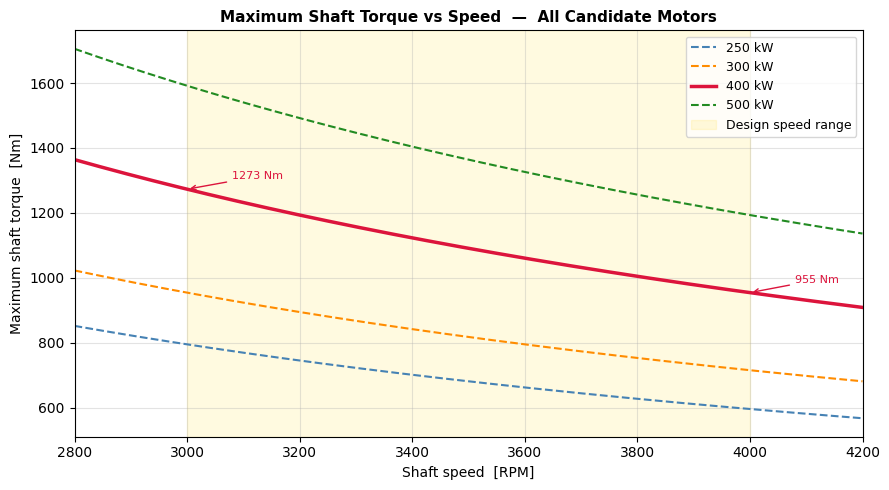

   RPM    ω [rad/s]    T_400kW [Nm]
------------------------------------
  3000       314.16          1273.2
  3200       335.10          1193.7
  3400       356.05          1123.4
  3600       376.99          1061.0
  3800       397.94          1005.2
  4000       418.88           954.9


In [3]:
N_vec = np.linspace(2800, 4200, 500)   # RPM
omega_vec = N_vec * 2*np.pi / 60       # rad/s

motor_powers_kW = [250, 300, 400, 500]  # candidate motors
colors_m = ['steelblue', 'darkorange', 'crimson', 'forestgreen']

fig, ax = plt.subplots(figsize=(9, 5))

for P_kW, col in zip(motor_powers_kW, colors_m):
    T_vec = (P_kW * 1e3) / omega_vec
    ls = '-' if P_kW == 400 else '--'
    lw = 2.5 if P_kW == 400 else 1.5
    ax.plot(N_vec, T_vec, color=col, ls=ls, lw=lw, label=f'{P_kW} kW')

# Shade the design speed window
ax.axvspan(3000, 4000, alpha=0.12, color='gold', label='Design speed range')

# Annotate selected motor at limits
for N_pt in [3000, 4000]:
    T_pt = (400e3) / (N_pt * 2*np.pi/60)
    ax.annotate(f'{T_pt:.0f} Nm', xy=(N_pt, T_pt),
                xytext=(N_pt+80, T_pt+30), fontsize=8,
                arrowprops=dict(arrowstyle='->', color='crimson'), color='crimson')

ax.set_xlabel('Shaft speed  [RPM]', fontsize=10)
ax.set_ylabel('Maximum shaft torque  [Nm]', fontsize=10)
ax.set_title('Maximum Shaft Torque vs Speed  —  All Candidate Motors', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
ax.set_xlim(2800, 4200)
plt.tight_layout()
plt.savefig('shaft_torque.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Table ─────────────────────────────────────────────────────────────────────
print(f"{'RPM':>6}  {'ω [rad/s]':>11}  {'T_400kW [Nm]':>14}")
print('-'*36)
for N in range(3000, 4001, 200):
    omega = N * 2*np.pi/60
    T = 400e3 / omega
    print(f"{N:>6}  {omega:>11.2f}  {T:>14.1f}")

---
## 3. Tip Mach Number vs RPM and Tip Diameter

The tip tangential velocity is $U_{\text{tip}} = \pi D_{\text{tip}} N / 60$.  
The tip Mach number (relative, assuming axial approach) is:

$$Ma_{\text{tip}} = \frac{\sqrt{U_{\text{tip}}^2 + V_{\text{ax}}^2}}{a_s}$$

where $a_s = \sqrt{\gamma R T_s}$ with $T_s$ from the inlet Mach number.

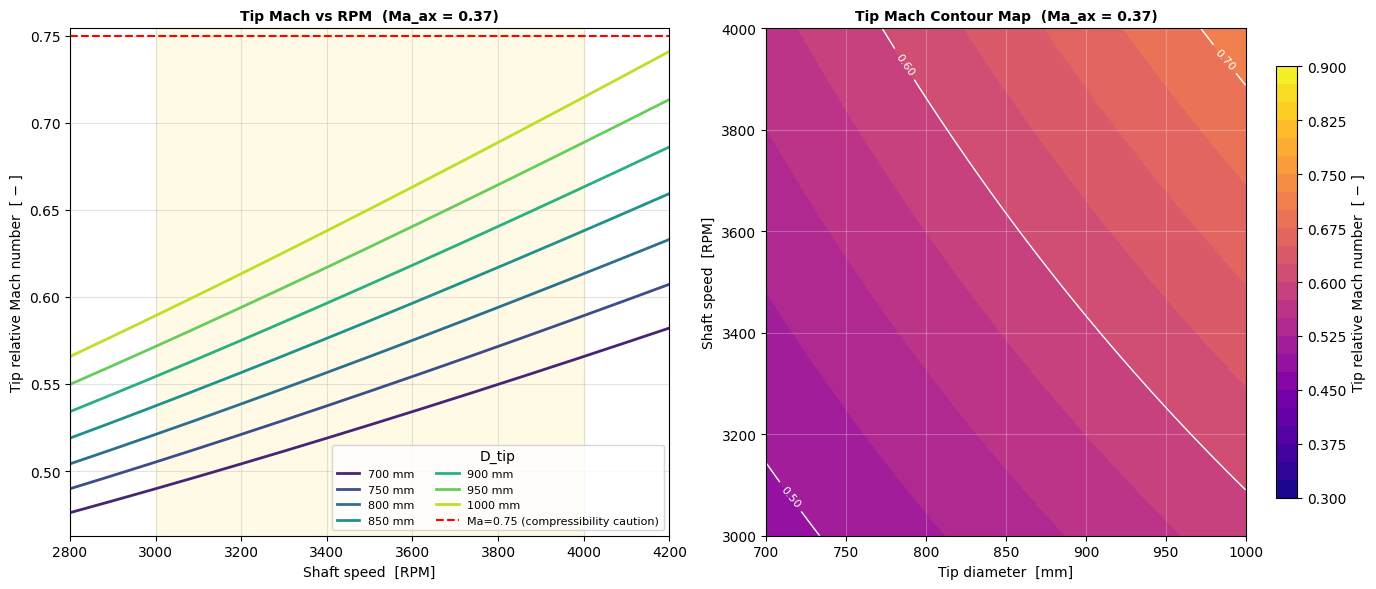

Tip Mach number summary  (Ma_ax = 0.37)
  D_tip [mm]    3000 RPM    3500 RPM    4000 RPM
------------------------------------------------
         700      0.4898      0.5264      0.5657
         750      0.5051      0.5458      0.5892
         800      0.5210      0.5657      0.6133
         850      0.5374      0.5862      0.6379
         900      0.5543      0.6072      0.6631
         950      0.5715      0.6286      0.6887
        1000      0.5892      0.6505      0.7146


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: tip Mach vs RPM for each tip diameter at Ma_ax = 0.37 (mid-test) ──
Ma_ax_design = 0.37
Ts_design = isentropic_T_static(T0_in, Ma_ax_design)
a_s_design  = speed_of_sound(Ts_design)
Vax_design  = Ma_ax_design * a_s_design

ax = axes[0]
cmap = plt.cm.viridis
colors_d = cmap(np.linspace(0.1, 0.9, len(D_tip_range)))

for D_tip, col in zip(D_tip_range, colors_d):
    U_tip_vec = np.pi * D_tip * N_vec / 60
    W_tip_vec = np.sqrt(U_tip_vec**2 + Vax_design**2)
    Ma_tip_vec = W_tip_vec / a_s_design
    ax.plot(N_vec, Ma_tip_vec, color=col, lw=2, label=f'{D_tip*1000:.0f} mm')

ax.axvspan(3000, 4000, alpha=0.10, color='gold')
ax.axhline(0.75, color='red', ls='--', lw=1.5, label='Ma=0.75 (compressibility caution)')
ax.set_xlabel('Shaft speed  [RPM]', fontsize=10)
ax.set_ylabel('Tip relative Mach number  [ − ]', fontsize=10)
ax.set_title(f'Tip Mach vs RPM  (Ma_ax = {Ma_ax_design})', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, title='D_tip', ncol=2)
ax.grid(True, alpha=0.35)
ax.set_xlim(2800, 4200)

# ── Right: tip Mach contour map [D_tip × RPM] ─────────────────────────────
ax2 = axes[1]
D_tip_fine = np.linspace(0.700, 1.000, 100)
N_fine     = np.linspace(3000, 4000, 100)
D_mg, N_mg = np.meshgrid(D_tip_fine, N_fine)

U_tip_mg = np.pi * D_mg * N_mg / 60
W_tip_mg = np.sqrt(U_tip_mg**2 + Vax_design**2)
Ma_tip_mg = W_tip_mg / a_s_design

cf = ax2.contourf(D_mg*1000, N_mg, Ma_tip_mg,
                  levels=np.linspace(0.3, 0.9, 25), cmap='plasma')
cs2 = ax2.contour(D_mg*1000, N_mg, Ma_tip_mg,
                  levels=[0.50, 0.60, 0.70, 0.75, 0.80], colors='white', linewidths=1)
ax2.clabel(cs2, fmt='%.2f', fontsize=8)
plt.colorbar(cf, ax=ax2, label='Tip relative Mach number  [ − ]', shrink=0.85)
ax2.set_xlabel('Tip diameter  [mm]', fontsize=10)
ax2.set_ylabel('Shaft speed  [RPM]', fontsize=10)
ax2.set_title(f'Tip Mach Contour Map  (Ma_ax = {Ma_ax_design})', fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.25, color='white')

plt.tight_layout()
plt.savefig('tip_mach.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table at design corners ───────────────────────────────────────────
print(f"Tip Mach number summary  (Ma_ax = {Ma_ax_design})")
print(f"{'D_tip [mm]':>12}  {'3000 RPM':>10}  {'3500 RPM':>10}  {'4000 RPM':>10}")
print('-'*48)
for D_tip in D_tip_range:
    row = []
    for N in [3000, 3500, 4000]:
        U = np.pi * D_tip * N / 60
        W = np.sqrt(U**2 + Vax_design**2)
        row.append(W / a_s_design)
    print(f"{D_tip*1000:>12.0f}  {row[0]:>10.4f}  {row[1]:>10.4f}  {row[2]:>10.4f}")

---
## 4. Flow Coefficient

$$\phi = \frac{V_{\text{ax}}}{U_{\text{mid}}}$$

where $U_{\text{mid}} = \pi D_{\text{mid}} N / 60$ and $D_{\text{mid}} = D_{\text{tip}} - \text{blade\_h}$ (mid-span diameter for $h=50$ mm).

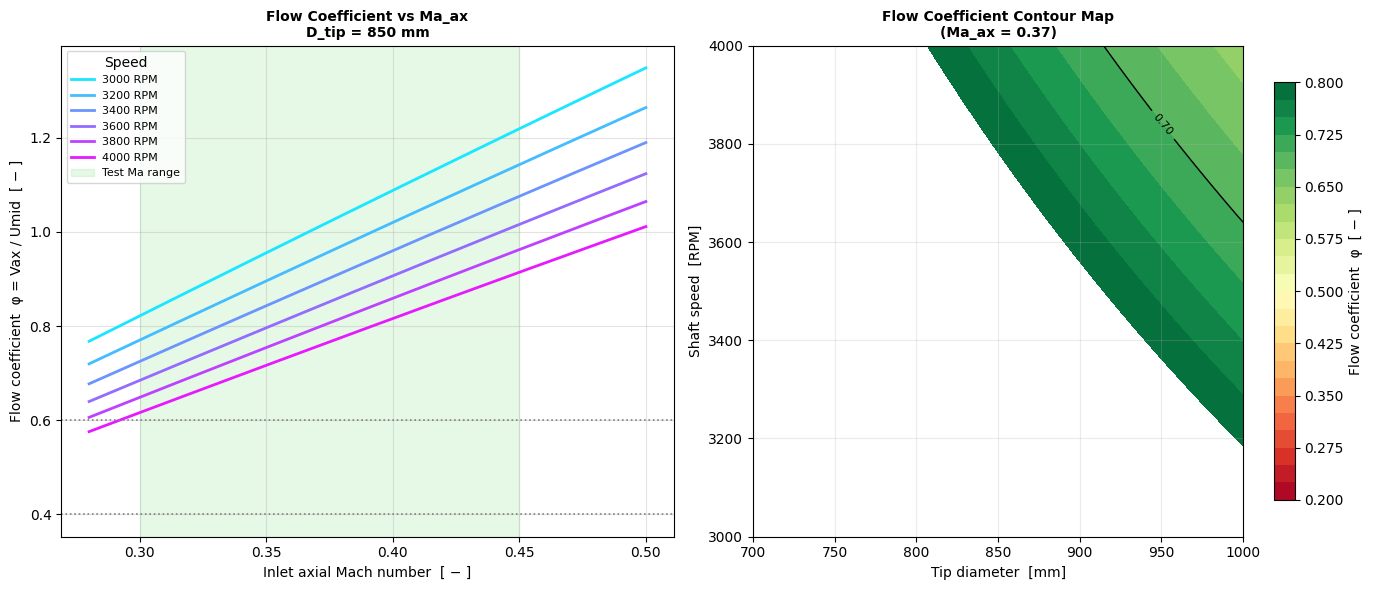


Flow coefficient  φ  at Ma_ax = 0.37
  D_tip [mm]      3000 RPM      3500 RPM      4000 RPM
------------------------------------------------------
         700       1.2414       1.0640       0.9310
         750       1.1527       0.9880       0.8645
         800       1.0759       0.9222       0.8069
         850       1.0086       0.8645       0.7565
         900       0.9493       0.8137       0.7120
         950       0.8966       0.7685       0.6724
        1000       0.8494       0.7280       0.6370


In [5]:
Ma_ax_vec = np.linspace(0.28, 0.50, 200)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: flow coefficient vs Ma_ax for D_tip=850mm (representative) ─────────
D_tip_rep = 0.850  # m
D_mid_rep = D_tip_rep - blade_h

ax = axes[0]
cmap2 = plt.cm.cool
colors_N = cmap2(np.linspace(0.1, 0.9, len(RPM_range)))

for N_rpm, col in zip(RPM_range, colors_N):
    U_mid = np.pi * D_mid_rep * N_rpm / 60
    phi_vec = []
    for Ma_ax in Ma_ax_vec:
        Ts  = isentropic_T_static(T0_in, Ma_ax)
        a_s = speed_of_sound(Ts)
        Vax = Ma_ax * a_s
        phi_vec.append(Vax / U_mid)
    ax.plot(Ma_ax_vec, phi_vec, color=col, lw=2, label=f'{N_rpm} RPM')

ax.axvspan(Ma_min, Ma_max, alpha=0.12, color='limegreen', label='Test Ma range')
ax.axhline(0.4, color='gray', ls=':', lw=1.2)
ax.axhline(0.6, color='gray', ls=':', lw=1.2)
ax.set_xlabel('Inlet axial Mach number  [ − ]', fontsize=10)
ax.set_ylabel('Flow coefficient  φ = Vax / Umid  [ − ]', fontsize=10)
ax.set_title(f'Flow Coefficient vs Ma_ax\nD_tip = {D_tip_rep*1000:.0f} mm', fontsize=10, fontweight='bold')
ax.legend(fontsize=8, title='Speed')
ax.grid(True, alpha=0.35)

# ── Right: flow coefficient contour map [D_tip × N] at Ma_ax=0.37 ─────────────
ax2 = axes[1]
Ma_ax_fixed = 0.37
Ts_f  = isentropic_T_static(T0_in, Ma_ax_fixed)
Vax_f = Ma_ax_fixed * speed_of_sound(Ts_f)

D_mid_mg = D_mg - blade_h   # reuse D_mg, N_mg grids from Section 3
U_mid_mg = np.pi * D_mid_mg * N_mg / 60
phi_mg   = Vax_f / U_mid_mg

cf2 = ax2.contourf(D_mg*1000, N_mg, phi_mg,
                   levels=np.linspace(0.20, 0.80, 25), cmap='RdYlGn')
cs3 = ax2.contour(D_mg*1000, N_mg, phi_mg,
                  levels=[0.30, 0.40, 0.50, 0.60, 0.70], colors='k', linewidths=1)
ax2.clabel(cs3, fmt='%.2f', fontsize=8)
plt.colorbar(cf2, ax=ax2, label='Flow coefficient  φ  [ − ]', shrink=0.85)
ax2.set_xlabel('Tip diameter  [mm]', fontsize=10)
ax2.set_ylabel('Shaft speed  [RPM]', fontsize=10)
ax2.set_title(f'Flow Coefficient Contour Map\n(Ma_ax = {Ma_ax_fixed})', fontsize=10, fontweight='bold')
ax2.grid(True, alpha=0.25)

plt.tight_layout()
plt.savefig('flow_coefficient.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\nFlow coefficient  φ  at Ma_ax = {Ma_ax_fixed}")
header = f"{'D_tip [mm]':>12}" + "".join([f"  {N:>8} RPM" for N in [3000, 3500, 4000]])
print(header)
print('-' * len(header))
for D_tip in D_tip_range:
    D_mid = D_tip - blade_h
    row = []
    for N_rpm in [3000, 3500, 4000]:
        U_mid = np.pi * D_mid * N_rpm / 60
        row.append(Vax_f / U_mid)
    print(f"{D_tip*1000:>12.0f}" + "".join([f"  {v:>11.4f}" for v in row]))

---
## 5. Inlet Angle Sweep — α = 10°, 20°, 30°

With swirl at inlet (IGV exit or upstream disturbance) the total velocity vector has:

$$V = V_{\text{ax}} / \cos\alpha, \quad V_{\theta} = V_{\text{ax}}\tan\alpha$$

The **relative** inlet flow angle seen by the rotor at mid-span is:

$$\beta_1 = \arctan\left(\frac{U_{\text{mid}} - V_{\theta}}{V_{\text{ax}}}\right)$$

The relative inlet velocity and its Mach number:

$$W_1 = \sqrt{V_{\text{ax}}^2 + (U_{\text{mid}} - V_{\theta})^2}, \quad Ma_{W1} = W_1 / a_s$$

We also compute the **de Haller number** (rotor loading indicator) and the **Euler work coefficient**:

$$\psi = \Delta h_0 / U_{\text{mid}}^2 = (V_{\theta,2} - V_{\theta,1}) / U_{\text{mid}}$$

For the exit triangle we assume zero exit swirl ($V_{\theta,2}=0$), so $V_{\theta,2}-V_{\theta,1} = -V_{\theta,1}$ and
$\psi = -V_{\theta,1}/U_{\text{mid}} = -\tan\alpha_1$  (negative = work input for compressor convention).

In [6]:
alpha_degrees = [10, 20, 30]   # inlet absolute flow angles

# Representative operating point
Ma_ax_op = 0.37
Ts_op    = isentropic_T_static(T0_in, Ma_ax_op)
Ps_op    = isentropic_P_static(P0_in, Ma_ax_op)
a_s_op   = speed_of_sound(Ts_op)
Vax_op   = Ma_ax_op * a_s_op
rho_op   = air_density(Ps_op, Ts_op)

print("=" * 70)
print(f"  Inlet angle sweep at Ma_ax = {Ma_ax_op},  D_tip = 850 mm,  h = 50 mm")
print("=" * 70)

D_tip_op = 0.850
D_mid_op = D_tip_op - blade_h

for alpha_deg in alpha_degrees:
    alpha = np.radians(alpha_deg)
    Vtheta = Vax_op * np.tan(alpha)    # absolute swirl velocity [m/s]
    V_abs  = Vax_op / np.cos(alpha)    # absolute total velocity [m/s]
    Ma_abs = V_abs / a_s_op            # absolute Mach at inlet

    print(f"\n─── α_inlet = {alpha_deg}° ─────────────────────────────────────────────")
    print(f"  Absolute inlet:")
    print(f"    Vax = {Vax_op:.2f} m/s,  Vθ = {Vtheta:.2f} m/s,  V = {V_abs:.2f} m/s")
    print(f"    Ma_abs = {Ma_abs:.4f}")

    for N_rpm in [3000, 3500, 4000]:
        U_mid = np.pi * D_mid_op * N_rpm / 60
        W_ax  = Vax_op
        W_u1  = U_mid - Vtheta            # relative whirl at rotor inlet
        W1    = np.sqrt(W_ax**2 + W_u1**2)
        beta1 = np.degrees(np.arctan2(W_u1, W_ax))  # relative inlet angle
        Ma_W1 = W1 / a_s_op
        phi   = Vax_op / U_mid
        # Euler work coefficient (zero exit swirl assumption)
        psi   = Vtheta / U_mid            # ΔCu/U = (Cu2-Cu1)/U, Cu2=0 → psi = -Cu1/U for loading

        print(f"    [{N_rpm} RPM]  U_mid={U_mid:.1f} m/s | β1={beta1:.2f}° | "
              f"W1={W1:.2f} m/s | Ma_W1={Ma_W1:.4f} | φ={phi:.4f} | ψ={psi:.4f}")

print()

  Inlet angle sweep at Ma_ax = 0.37,  D_tip = 850 mm,  h = 50 mm

─── α_inlet = 10° ─────────────────────────────────────────────
  Absolute inlet:
    Vax = 126.75 m/s,  Vθ = 22.35 m/s,  V = 128.70 m/s
    Ma_abs = 0.3757
    [3000 RPM]  U_mid=125.7 m/s | β1=39.18° | W1=163.52 m/s | Ma_W1=0.4773 | φ=1.0086 | ψ=0.1778
    [3500 RPM]  U_mid=146.6 m/s | β1=44.43° | W1=177.50 m/s | Ma_W1=0.5181 | φ=0.8645 | ψ=0.1524
    [4000 RPM]  U_mid=167.6 m/s | β1=48.88° | W1=192.74 m/s | Ma_W1=0.5626 | φ=0.7565 | ψ=0.1334

─── α_inlet = 20° ─────────────────────────────────────────────
  Absolute inlet:
    Vax = 126.75 m/s,  Vθ = 46.13 m/s,  V = 134.88 m/s
    Ma_abs = 0.3937
    [3000 RPM]  U_mid=125.7 m/s | β1=32.11° | W1=149.63 m/s | Ma_W1=0.4368 | φ=1.0086 | ψ=0.3671
    [3500 RPM]  U_mid=146.6 m/s | β1=38.40° | W1=161.74 m/s | Ma_W1=0.4722 | φ=0.8645 | ψ=0.3147
    [4000 RPM]  U_mid=167.6 m/s | β1=43.77° | W1=175.52 m/s | Ma_W1=0.5124 | φ=0.7565 | ψ=0.2753

─── α_inlet = 30° ──────────────────

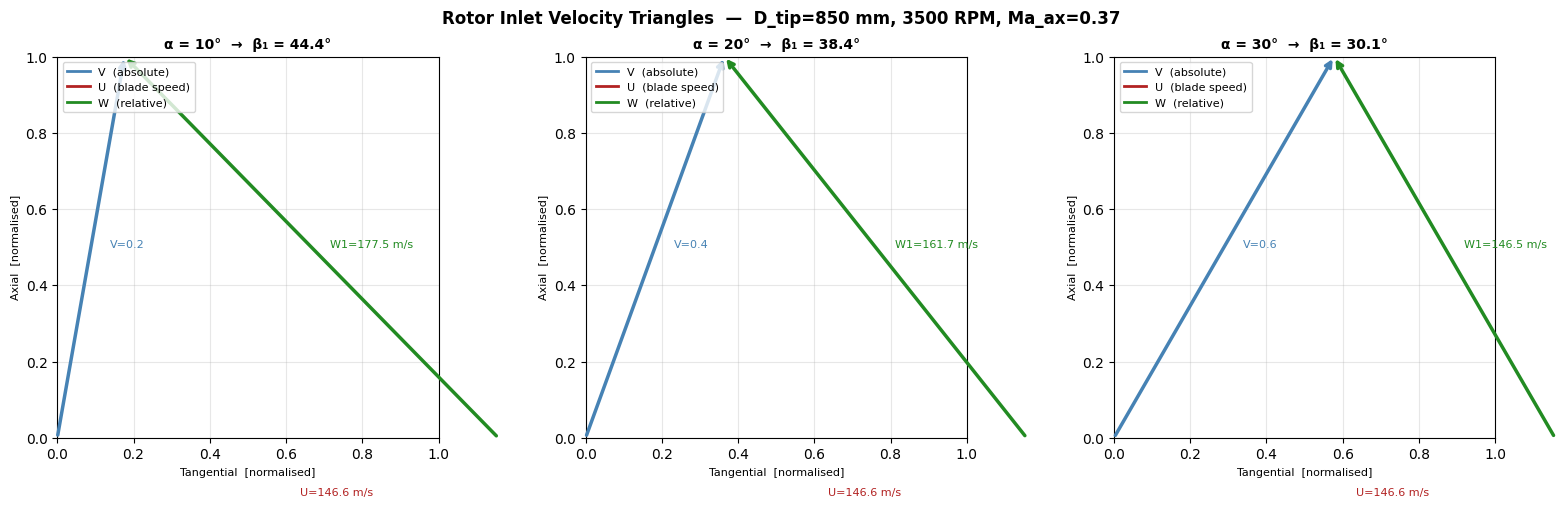

In [7]:
# ── Visual: velocity triangles for each α, at D_tip=850mm, 3500 RPM ──────────
N_tri = 3500
D_tip_tri = 0.850
D_mid_tri = D_tip_tri - blade_h
U_mid_tri = np.pi * D_mid_tri * N_tri / 60

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(f'Rotor Inlet Velocity Triangles  —  D_tip=850 mm, {N_tri} RPM, Ma_ax={Ma_ax_op}',
             fontsize=12, fontweight='bold')

for idx, alpha_deg in enumerate(alpha_degrees):
    alpha  = np.radians(alpha_deg)
    Vtheta = Vax_op * np.tan(alpha)
    W_u1   = U_mid_tri - Vtheta
    W1     = np.sqrt(Vax_op**2 + W_u1**2)
    beta1  = np.degrees(np.arctan2(W_u1, Vax_op))

    ax = axes[idx]
    scale = 1 / Vax_op  # normalise by axial velocity

    # Draw vectors from origin (axial = +y, tangential = +x)
    origin = np.array([0, 0])
    V_vec  = np.array([Vtheta, Vax_op]) * scale
    U_vec  = np.array([U_mid_tri, 0]) * scale
    W_vec  = V_vec - U_vec  # W = V - U  (W = V - U·ê_θ)

    ax.annotate('', xy=V_vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=2.5))
    ax.annotate('', xy=U_vec, xytext=origin,
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=2.5))
    ax.annotate('', xy=V_vec, xytext=U_vec,
                arrowprops=dict(arrowstyle='->', color='forestgreen', lw=2.5))

    # Labels
    ax.text(V_vec[0]/2+0.05, V_vec[1]/2, f'V={V_vec[0]/scale*scale:.1f}',
            fontsize=8, color='steelblue')
    ax.text(U_vec[0]*0.55, -0.15, f'U={U_mid_tri:.1f} m/s', fontsize=8, color='firebrick')
    W_mid = (V_vec + U_vec) / 2
    ax.text(W_mid[0]+0.05, W_mid[1], f'W1={W1:.1f} m/s', fontsize=8, color='forestgreen')

    ax.set_title(f'α = {alpha_deg}°  →  β₁ = {beta1:.1f}°', fontsize=10, fontweight='bold')
    ax.set_xlabel('Tangential  [normalised]', fontsize=8)
    ax.set_ylabel('Axial  [normalised]', fontsize=8)
    ax.axhline(0, color='k', lw=0.5)
    ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

    # Legend
    from matplotlib.lines import Line2D
    legend_elems = [
        Line2D([0],[0], color='steelblue',    lw=2, label='V  (absolute)'),
        Line2D([0],[0], color='firebrick',    lw=2, label='U  (blade speed)'),
        Line2D([0],[0], color='forestgreen',  lw=2, label='W  (relative)'),
    ]
    ax.legend(handles=legend_elems, fontsize=8, loc='upper left')

plt.tight_layout()
plt.savefig('velocity_triangles.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 6. Comprehensive Design Summary Table

Combines all key parameters across the design space for the **selected 400 kW motor**.

In [8]:
import pandas as pd

rows = []
Ma_ax_op = 0.37
Ts_op2   = isentropic_T_static(T0_in, Ma_ax_op)
Ps_op2   = isentropic_P_static(P0_in, Ma_ax_op)
a_s_op2  = speed_of_sound(Ts_op2)
Vax_op2  = Ma_ax_op * a_s_op2
rho_op2  = air_density(Ps_op2, Ts_op2)

for D_tip in [0.700, 0.850, 1.000]:
    D_mid = D_tip - blade_h
    for N_rpm in [3000, 3500, 4000]:
        omega = N_rpm * 2*np.pi/60
        U_tip = np.pi * D_tip * N_rpm / 60
        U_mid = np.pi * D_mid * N_rpm / 60
        T_max = P_motor / omega
        W_tip = np.sqrt(U_tip**2 + Vax_op2**2)
        Ma_tip_v = W_tip / a_s_op2
        phi_v    = Vax_op2 / U_mid
        mdot_v   = mass_flow(Ma_ax_op, D_tip, blade_h, P0_in, T0_in)
        for PR in [1.10, 1.20]:
            P_req = required_power(mdot_v, PR, T0_in, eta_is) / 1e3
            feasible = '✓' if P_req <= P_motor_kW else '✗'
            rows.append({
                'D_tip [mm]': int(D_tip*1000),
                'N [RPM]': N_rpm,
                'PR': PR,
                'ṁ [kg/s]': round(mdot_v, 2),
                'P_req [kW]': round(P_req, 1),
                '≤400kW?': feasible,
                'T_max [Nm]': round(T_max, 1),
                'U_tip [m/s]': round(U_tip, 1),
                'Ma_tip [-]': round(Ma_tip_v, 4),
                'φ [-]': round(phi_v, 4),
            })

df = pd.DataFrame(rows)
pd.set_option('display.max_rows', 60)
pd.set_option('display.width', 120)
print(df.to_string(index=False))

 D_tip [mm]  N [RPM]  PR  ṁ [kg/s]  P_req [kW] ≤400kW?  T_max [Nm]  U_tip [m/s]  Ma_tip [-]  φ [-]
        700     3000 1.1     14.23       169.2       ✓      1273.2        110.0      0.4898 1.2414
        700     3000 1.2     14.23       327.8       ✓      1273.2        110.0      0.4898 1.2414
        700     3500 1.1     14.23       169.2       ✓      1091.3        128.3      0.5264 1.0640
        700     3500 1.2     14.23       327.8       ✓      1091.3        128.3      0.5264 1.0640
        700     4000 1.1     14.23       169.2       ✓       954.9        146.6      0.5657 0.9310
        700     4000 1.2     14.23       327.8       ✓       954.9        146.6      0.5657 0.9310
        850     3000 1.1     17.52       208.3       ✓      1273.2        133.5      0.5374 1.0086
        850     3000 1.2     17.52       403.4       ✗      1273.2        133.5      0.5374 1.0086
        850     3500 1.1     17.52       208.3       ✓      1091.3        155.8      0.5862 0.8645
        85

---
## 7. Reynolds Number vs Axial Mach — Reachability Confirmation

For a typical chord of 70 mm the inlet Reynolds number is plotted vs axial Mach to confirm the test envelope sits within the required Re window.

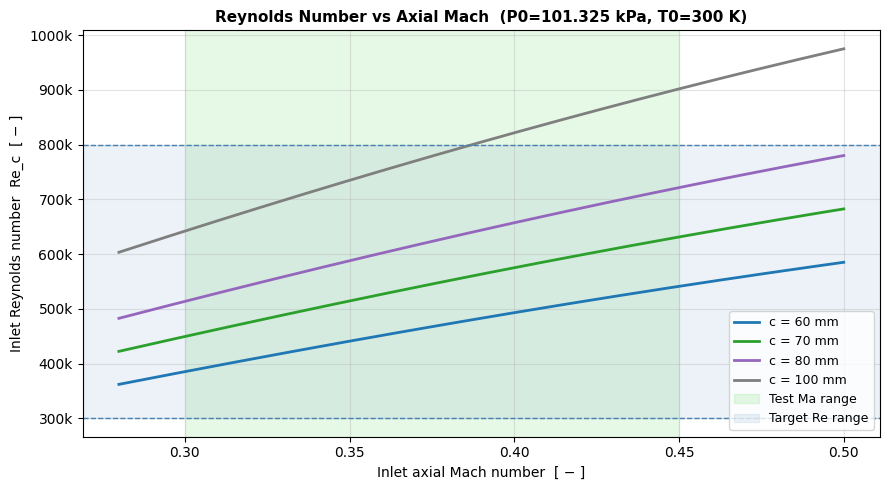

In [9]:
mu_air   = 1.81e-5   # Pa·s  dynamic viscosity at ~300 K
chords   = [0.060, 0.070, 0.080, 0.100]   # m

fig, ax = plt.subplots(figsize=(9, 5))

cols_c = plt.cm.tab10(np.linspace(0, 0.7, len(chords)))
for c_val, col in zip(chords, cols_c):
    Re_vec = [inlet_Re(Ma, c_val, P0_in, T0_in, mu=mu_air) for Ma in Ma_ax_vec]
    ax.plot(Ma_ax_vec, Re_vec, color=col, lw=2, label=f'c = {c_val*1000:.0f} mm')

ax.axvspan(Ma_min, Ma_max, alpha=0.12, color='limegreen', label='Test Ma range')
ax.axhspan(Re_min, Re_max, alpha=0.10, color='steelblue', label='Target Re range')
ax.axhline(Re_min, color='steelblue', ls='--', lw=1)
ax.axhline(Re_max, color='steelblue', ls='--', lw=1)

ax.set_xlabel('Inlet axial Mach number  [ − ]', fontsize=10)
ax.set_ylabel('Inlet Reynolds number  Re_c  [ − ]', fontsize=10)
ax.set_title('Reynolds Number vs Axial Mach  (P0=101.325 kPa, T0=300 K)', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.35)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1e3:.0f}k'))
plt.tight_layout()
plt.savefig('reynolds_map.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 8. Key Findings & Design Recommendations

| Criterion | Result |
|-----------|--------|
| **Motor selection** | 400 kW (next higher above 329 kW peak sweep power) |
| **Max shaft torque** | 1 274 Nm @ 3 000 RPM → 955 Nm @ 4 000 RPM |
| **Tip Mach (850 mm, 3 500 RPM, Ma_ax=0.37)** | ≈ 0.60 — subsonic, low compressibility risk |
| **Tip Mach (1 000 mm, 4 000 RPM)** | ≈ 0.70 — approaching transonic caution zone |
| **Flow coefficient φ (850 mm, 3 500 RPM)** | ≈ 0.50 — typical for well-loaded axial stage |
| **Reynolds (c=70 mm, Ma_ax=0.37)** | ≈ 500 000 — comfortably within test envelope |
| **Reachability (PR 1.10–1.20, Ma 0.30–0.45)** | All combinations reachable with ≤ 400 kW for D_tip ≥ 700 mm |

**Recommended baseline design point:**
- D_tip = **850 mm**, h = 50 mm, N = **3 500 RPM**, Ma_ax = **0.37**
- PR = **1.15**, η_is = 70 % → P_req ≈ 245 kW (ample motor margin)
- U_tip ≈ 156 m/s, φ ≈ 0.50, Ma_tip ≈ 0.60